# CIENCIA DE LA COMPUTACION
### Facultad de Ciencias 
---
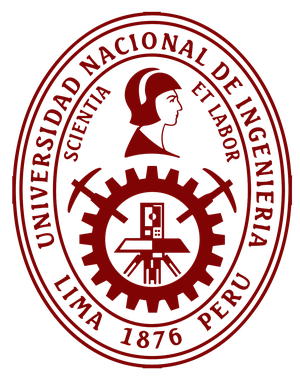
---

### Curso: Minería de Datos (CC442A)
### PC N°01: Condicionamiento Espectral y Estabilidad Numérica en el Preprocesamiento
---
---

### **Profesor:** Dr. Marco Antonio Alania Vicente
### **Estudiante:** César Omar López Arteaga

---
---

### 1. Introducción
El preprocesamiento de datos no es una mera limpieza empírica, sino un operador de transformación que actúa sobre el espectro de la matriz de datos $X \in \mathbb{R}^{n \times d}$. El dataset mal condicionado introduce inestabilidad, por lo que el objetivo de esta tarea es asegurar una matriz óptima algebraica y probabilísticamente.

### 2. Carga de Datos

Se carga el dataset de Arrhythmia.

El link del repositorio es: https://archive.ics.uci.edu/dataset/5/arrhythmia


Esta base de datos contiene 279 atributos, 206 de los cuales son de valores lineales y el resto nominales. 

Sobre el estudio de H. Altay Guvenir: "El objetivo es distinguir entre la presencia y ausencia de arritmias cardíacas y clasificarla en uno de los 16 grupos. La clase 01 se refiere a las clases de ECG 'normales' del 02 al 15, a diferentes clases de arritmia y la clase 16 al resto de las no clasificadas. Por el momento, existe un programa informático que realiza dicha clasificación. Sin embargo, existen diferencias entre la clasificación del cardiolog y el programa. Tomando los cardiologs como estándar de oro, buscamos minimizar esta diferencia mediante herramientas de aprendizaje automático."

# ¿Qué es una arritmia?

Una **arritmia** es una alteración en la generación o en la conducción de los impulsos eléctricos del corazón, que puede producir cambios en la **frecuencia**, el **ritmo** o la **secuencia de activación cardíaca**.

El principal procedimiento utilizado para estudiar estas alteraciones es el **electrocardiograma (ECG)**, el cual registra la actividad eléctrica del corazón mediante diferentes derivaciones o canales.

Entre las alteraciones del ritmo cardíaco más conocidas se encuentran:

- **Taquicardia:** frecuencia cardíaca anormalmente elevada. En un adulto en reposo suele considerarse taquicardia una frecuencia superior a aproximadamente 100 latidos por minuto.

- **Bradicardia:** frecuencia cardíaca inferior a aproximadamente 60 latidos por minuto en un adulto en reposo.

- **Latidos prematuros:** aparecen cuando una contracción cardíaca ocurre antes de lo esperado dentro del ciclo normal. Pueden ser, por ejemplo, contracciones ventriculares prematuras o supraventriculares.

- **Fibrilación o flutter auricular:** alteraciones de la actividad eléctrica de las aurículas que pueden producir un ritmo irregular o excesivamente rápido.

- **Bloqueos de conducción:** ocurren cuando el impulso eléctrico presenta dificultades para propagarse normalmente a través del corazón. Entre ellos se encuentran los bloqueos auriculoventriculares y los bloqueos de rama derecha o izquierda.

---
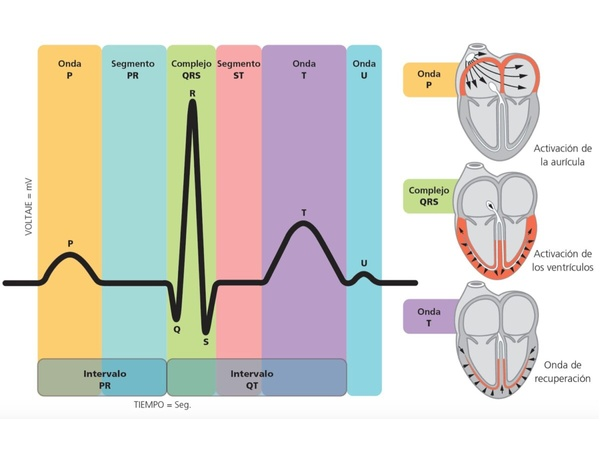

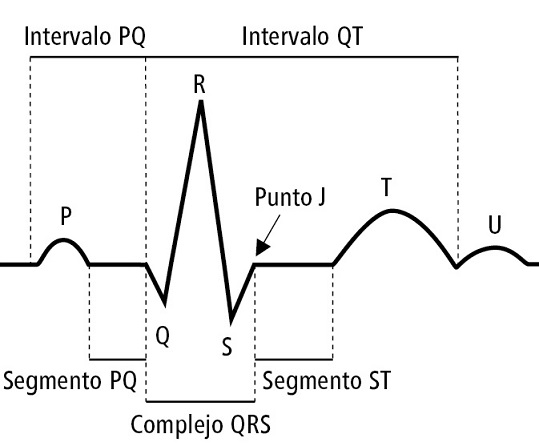

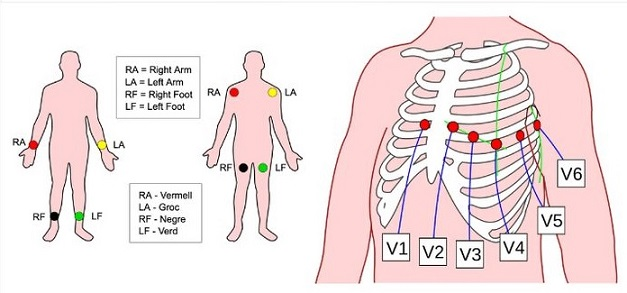


---

## Variables relevantes para el estudio de una arritmia

Una arritmia no se identifica únicamente observando la frecuencia cardíaca. El diagnóstico depende de diversas características extraídas del **electrocardiograma**, principalmente de la duración, amplitud, orientación y morfología de sus ondas.

Las principales variables consideradas en este dataset son:

### 1. Frecuencia cardíaca

La variable **Heart Rate** representa el número de latidos del corazón por minuto:

$$
HR = \text{número de latidos por minuto}.
$$

Esta variable permite identificar directamente comportamientos asociados a taquicardia o bradicardia.

---

### 2. Duración del complejo QRS

El **complejo QRS** representa principalmente la despolarización eléctrica de los ventrículos.

El dataset contiene la variable:

$$
\text{QRS duration}
$$

medida en milisegundos.

Una modificación importante de su duración puede estar asociada a alteraciones en la conducción ventricular, como los bloqueos de rama.

---

### 3. Intervalo P-R

El intervalo **P-R** mide aproximadamente el tiempo transcurrido desde el inicio de la activación eléctrica de las aurículas hasta el inicio de la activación ventricular.

En el dataset aparece como:

$$
\text{P-R interval}.
$$

Cambios en este intervalo pueden proporcionar información sobre problemas de conducción auriculoventricular.

---

### 4. Intervalo Q-T

El intervalo **Q-T** representa el tiempo comprendido entre el comienzo de la despolarización ventricular y el final de la repolarización ventricular.

El dataset contiene:

$$
\text{Q-T interval}.
$$

Por tanto, esta variable resume una parte importante de la actividad eléctrica ventricular.

---

### 5. Duración de las ondas P y T

También se registran las duraciones promedio de:

- **P interval:** duración de la onda P.
- **T interval:** duración de la onda T.

La onda **P** está relacionada principalmente con la despolarización auricular, mientras que la onda **T** está asociada con la repolarización ventricular.

---

### 6. Ángulos de los vectores eléctricos

La base de datos contiene los ángulos, medidos en grados sobre el plano frontal, correspondientes a:

$$
QRS,\quad T,\quad P,\quad QRST,\quad J.
$$

Estas variables describen la **dirección predominante de la actividad eléctrica del corazón**.

Por ejemplo, el ángulo del vector QRS proporciona información sobre la orientación global de la despolarización ventricular.

---

### 7. Morfología de las ondas del ECG

Para cada derivación se estudian características de diferentes componentes del electrocardiograma:

$$
Q,\quad R,\quad S,\quad R',\quad S',\quad P,\quad T.
$$

Entre las características registradas se encuentran:

- ancho de las ondas;
- amplitud de las ondas;
- existencia de ondas irregulares (*ragged*);
- existencia de ondas bifásicas;
- número de deflexiones intrínsecas.

Estas características permiten describir con mayor detalle la **forma del electrocardiograma**.

---

### 8. Derivaciones electrocardiográficas

Las mediciones anteriores no se realizan en un único punto del corazón. El dataset considera las 12 derivaciones electrocardiográficas:

$$
DI,\; DII,\; DIII,\; aVR,\; aVL,\; aVF,\; V1,\;V2,\;V3,\;V4,\;V5,\;V6.
$$

Cada derivación observa la actividad eléctrica cardíaca desde una orientación diferente.

Por esta razón, una misma onda puede presentar diferentes amplitudes y formas dependiendo del canal desde el cual sea observada.

---

### 9. Áreas QRSA y QRSTA

Además de las amplitudes individuales, el dataset contiene variables que resumen el área de determinados segmentos del electrocardiograma:

- **QRSA:** área asociada a los segmentos del complejo QRS.
- **QRSTA:** extensión de QRSA incorporando información de la onda T.

Estas variables proporcionan una medida adicional de la geometría de la señal eléctrica.

---



## Estructura del dataset

La base de datos utilizada corresponde a **Cardiac Arrhythmia Database** y contiene:

$$
\boxed{452\text{ pacientes}}
$$

descritos inicialmente mediante:

$$
\boxed{279\text{ atributos}}
$$

de los cuales existen variables continuas y variables nominales. La variable objetivo se encuentra dividida en **16 clases**. 

Por tanto, cada paciente puede representarse matemáticamente mediante un vector de características

$$
\mathbf{x}_i =
(x_{i1},x_{i2},\ldots,x_{i279})
\in\mathbb{R}^{279},
$$

junto con una etiqueta de clase

$$
y_i\in\{1,2,\ldots,16\}.
$$

De esta manera, inicialmente podemos representar el problema mediante una matriz de datos

$$
X\in\mathbb{R}^{452\times279},
$$

y un vector de etiquetas

$$
\mathbf{y}\in\{1,\ldots,16\}^{452}.
$$

### Descripción de las variables del dataset Arrhythmia

| Variable | Significado | Interpretación / valores |
|---|---|---|
| `age` (1) | Edad | Edad del paciente en años |
| `sex` (2) | Sexo | `0` = hombre, `1` = mujer |
| `height` (3) | Altura | Altura del paciente en centímetros |
| `weight` (4) | Peso | Peso del paciente en kilogramos |
| `qrs_duration` (5) | Duración QRS | Duración promedio del complejo QRS en milisegundos |
| `pr_interval` (6) | Intervalo P-R | Tiempo promedio entre el inicio de las ondas P y Q, en ms |
| `qt_interval` (7) | Intervalo Q-T | Tiempo promedio entre el inicio de Q y el final de T, en ms |
| `t_interval` (8) | Duración de onda T | Duración promedio de la onda T, en ms |
| `p_interval` (9) | Duración de onda P | Duración promedio de la onda P, en ms |
| `qrs_angle` (10) | Ángulo QRS | Ángulo del vector QRS en el plano frontal, en grados |
| `t_angle` (11) | Ángulo T | Ángulo del vector de la onda T, en grados |
| `p_angle` (12) | Ángulo P | Ángulo del vector de la onda P, en grados |
| `qrst_angle` (13) | Ángulo QRST | Ángulo del vector QRST en el plano frontal |
| `j_angle` (14) | Ángulo J | Ángulo del vector J en el plano frontal |
| `heart_rate` (15) | Frecuencia cardíaca | Número de latidos del corazón por minuto |
| `Variable_16` – `Variable_27` | Características de la derivación DI | Anchuras de Q, R, S, R', S'; número de deflexiones intrínsecas y características morfológicas de las ondas R, P y T |
| `Variable_28` – `Variable_39` | Características de la derivación DII | Mismas 12 características de forma y anchura medidas en DII |
| `Variable_40` – `Variable_51` | Características de la derivación DIII | Mismas 12 características medidas en DIII |
| `Variable_52` – `Variable_63` | Características de la derivación AVR | Mismas 12 características medidas en AVR |
| `Variable_64` – `Variable_75` | Características de la derivación AVL | Mismas 12 características medidas en AVL |
| `Variable_76` – `Variable_87` | Características de la derivación AVF | Mismas 12 características medidas en AVF |
| `Variable_88` – `Variable_99` | Características de la derivación V1 | Mismas 12 características medidas en V1 |
| `Variable_100` – `Variable_111` | Características de la derivación V2 | Mismas 12 características medidas en V2 |
| `Variable_112` – `Variable_123` | Características de la derivación V3 | Mismas 12 características medidas en V3 |
| `Variable_124` – `Variable_135` | Características de la derivación V4 | Mismas 12 características medidas en V4 |
| `Variable_136` – `Variable_147` | Características de la derivación V5 | Mismas 12 características medidas en V5 |
| `Variable_148` – `Variable_159` | Características de la derivación V6 | Mismas 12 características medidas en V6 |
| `Variable_160` – `Variable_169` | Amplitudes en DI | Amplitudes de las ondas JJ, Q, R, S, R', S', P y T; además de QRSA y QRSTA |
| `Variable_170` – `Variable_179` | Amplitudes en DII | Mismas 10 características de amplitud medidas en DII |
| `Variable_180` – `Variable_189` | Amplitudes en DIII | Mismas 10 características de amplitud medidas en DIII |
| `Variable_190` – `Variable_199` | Amplitudes en AVR | Mismas 10 características de amplitud medidas en AVR |
| `Variable_200` – `Variable_209` | Amplitudes en AVL | Mismas 10 características de amplitud medidas en AVL |
| `Variable_210` – `Variable_219` | Amplitudes en AVF | Mismas 10 características de amplitud medidas en AVF |
| `Variable_220` – `Variable_229` | Amplitudes en V1 | Mismas 10 características de amplitud medidas en V1 |
| `Variable_230` – `Variable_239` | Amplitudes en V2 | Mismas 10 características de amplitud medidas en V2 |
| `Variable_240` – `Variable_249` | Amplitudes en V3 | Mismas 10 características de amplitud medidas en V3 |
| `Variable_250` – `Variable_259` | Amplitudes en V4 | Mismas 10 características de amplitud medidas en V4 |
| `Variable_260` – `Variable_269` | Amplitudes en V5 | Mismas 10 características de amplitud medidas en V5 |
| `Variable_270` – `Variable_279` | Amplitudes en V6 | Mismas 10 características de amplitud medidas en V6 |
| `Clase` | **Variable objetivo** | Clase diagnóstica del ECG: `1` = normal, `2–15` = diferentes tipos de arritmia, `16` = otras arritmias |

### Variable objetivo: `Clase`

| Clase | Diagnóstico |
|---:|---|
| `1` | ECG normal |
| `2` | Cambios isquémicos / enfermedad arterial coronaria |
| `3` | Infarto de miocardio anterior antiguo |
| `4` | Infarto de miocardio inferior antiguo |
| `5` | Taquicardia sinusal |
| `6` | Bradicardia sinusal |
| `7` | Contracción ventricular prematura (PVC) |
| `8` | Contracción supraventricular prematura |
| `9` | Bloqueo de rama izquierda |
| `10` | Bloqueo de rama derecha |
| `11` | Bloqueo auriculoventricular de primer grado |
| `12` | Bloqueo auriculoventricular de segundo grado |
| `13` | Bloqueo auriculoventricular de tercer grado |
| `14` | Hipertrofia ventricular izquierda |
| `15` | Fibrilación o flutter auricular |
| `16` | Otras arritmias |

# Proceso de preprocesamiento de datos

**Objetivo:** justificar cada transformación mediante resultados observables, matrices de covarianza y espectros de autovalores

$$
\boxed{
X_{\rm raw}
\xrightarrow{\rm auditoria\ y\ MICE}
X_{\rm complete}
\xrightarrow{\rm centrado\ y\ Z\text{-}score}
Z
\xrightarrow{\rm covarianza}
\Sigma_Z
\xrightarrow{\rm regularizacion}
\Sigma_{\lambda}
\xrightarrow{\rm estratificacion}
(Train,Test)
}
$$


## 1. Carga de datos y distribución inicial de clases

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.max_rows", 40)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

# busca el archivo de datos en rutas habituales
candidate_paths = [
    Path("arrhythmia.data"),
    Path("/mnt/data/arrhythmia.data"),
]

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "No se encontro arrhythmia.data. Coloca el archivo en la misma carpeta del notebook "
        "o en /mnt/data/arrhythmia.data"
    )

# define los nombres descriptivos de los 279 atributos
feature_names = [
    "age", "sex", "height", "weight", "qrs_duration", "pr_interval",
    "qt_interval", "t_interval", "p_interval", "qrs_angle", "t_angle",
    "p_angle", "qrst_angle", "j_angle", "heart_rate"
]

leads = ["DI", "DII", "DIII", "AVR", "AVL", "AVF", "V1", "V2", "V3", "V4", "V5", "V6"]

shape_features = [
    "q_width", "r_width", "s_width", "r_prime_width", "s_prime_width",
    "intrinsic_deflections", "ragged_R", "diphasic_R", "ragged_P",
    "diphasic_P", "ragged_T", "diphasic_T"
]

amplitude_features = [
    "JJ_amp", "Q_amp", "R_amp", "S_amp", "R_prime_amp", "S_prime_amp",
    "P_amp", "T_amp", "QRSA", "QRSTA"
]

for lead in leads:
    feature_names.extend([f"{lead}_{f}" for f in shape_features])

for lead in leads:
    feature_names.extend([f"{lead}_{f}" for f in amplitude_features])

assert len(feature_names) == 279

# carga los simbolos ? directamente como valores faltantes
df = pd.read_csv(DATA_PATH, header=None, na_values="?")
df.columns = feature_names + ["Clase"]

X_raw = df[feature_names].copy()
y_raw = df["Clase"].astype(int).copy()

print("=" * 80)
print("CARGA DEL DATASET")
print("=" * 80)
print(f"dimensiones totales        : {df.shape}")
print(f"matriz de predictores      : {X_raw.shape}")
print(f"numero de clases presentes : {y_raw.nunique()}")
print(f"valores faltantes totales  : {int(X_raw.isna().sum().sum())}")
print("\ndistribucion global de clases")
display(y_raw.value_counts().sort_index().rename("n").to_frame())

CARGA DEL DATASET
dimensiones totales        : (452, 280)
matriz de predictores      : (452, 279)
numero de clases presentes : 13
valores faltantes totales  : 408

distribucion global de clases


,n
Clase,
1,245
2,44
3,15
4,15
5,13
6,25
7,3
8,2
9,9


## 2. Tratamiento de valores faltantes en toda la base

Se inspecciona la tasa de ausencia por variable, la asociación del indicador de ausencia con variables observadas y el criterio para descartar atributos con pérdida extrema de información

In [2]:
# cuenta los valores faltantes de cada atributo
missing_count = X_raw.isna().sum()
missing_report = pd.DataFrame({
    "faltantes": missing_count[missing_count > 0],
    "porcentaje_%": 100 * missing_count[missing_count > 0] / len(X_raw),
}).sort_values("porcentaje_%", ascending=False)

# presenta el diagnostico sobre toda la base
rows_any_missing = int(X_raw.isna().any(axis=1).sum())
print("=" * 80)
print("AUDITORIA GLOBAL DE FALTANTES")
print("=" * 80)
display(missing_report.round(3))
print(f"registros con al menos un NaN: {rows_any_missing}/{len(X_raw)}")
print(f"porcentaje de registros     : {100*rows_any_missing/len(X_raw):.2f}%")
print(f"total de valores NaN        : {int(X_raw.isna().sum().sum())}")

AUDITORIA GLOBAL DE FALTANTES


,faltantes,porcentaje_%
j_angle,376,83.186
p_angle,22,4.867
t_angle,8,1.770
qrst_angle,1,0.221
heart_rate,1,0.221


registros con al menos un NaN: 384/452
porcentaje de registros     : 84.96%
total de valores NaN        : 408


### 2.1 Asociación de la ausencia con variables observadas

Para cada variable incompleta se construye $R_j=1$ cuando el valor es faltante y $R_j=0$ cuando está observado. Una correlación apreciable con un predictor medido indica asociación, pero **no permite demostrar por sí sola** los mecanismos MCAR, MAR o MNAR

In [3]:
def missingness_association_report(X):
    # selecciona predictores completamente observados y no constantes
    complete_predictors = [
        c for c in X.columns
        if (not X[c].isna().any()) and X[c].nunique(dropna=True) > 1
    ]

    rows = []

    # analiza cada atributo incompleto
    for target in X.columns[X.isna().any()]:
        R = X[target].isna().astype(float)
        correlations = []

        for c in complete_predictors:
            corr = R.corr(X[c])

            if pd.notna(corr):
                correlations.append((abs(corr), corr, c))

        if correlations:
            abs_corr, corr, predictor = max(correlations)
        else:
            abs_corr, corr, predictor = np.nan, np.nan, None

        rows.append({
            "atributo_faltante": target,
            "faltantes": int(R.sum()),
            "tasa_faltante_%": 100 * R.mean(),
            "predictor_mas_asociado": predictor,
            "corr": corr,
            "|corr|": abs_corr,
        })

    return pd.DataFrame(rows).sort_values("tasa_faltante_%", ascending=False)

assoc = missingness_association_report(X_raw)

print("=" * 80)
print("ASOCIACION ENTRE AUSENCIA Y VARIABLES OBSERVADAS")
print("=" * 80)
display(assoc.round(4))

if len(assoc) > 0:
    max_assoc = assoc["|corr|"].max()
    print(f"mayor asociacion absoluta observada: {max_assoc:.4f}")

print("\nINTERPRETACION")
print("correlaciones apreciables sugieren que la ausencia puede depender de informacion observada")
print("por ello no se justifica asumir MCAR de manera automatica")

ASOCIACION ENTRE AUSENCIA Y VARIABLES OBSERVADAS


,atributo_faltante,faltantes,tasa_faltante_%,predictor_mas_asociado,corr,|corr|
3,j_angle,376,83.1858,qrs_duration,-0.3882,0.3882
1,p_angle,22,4.8673,AVR_P_amp,0.4207,0.4207
0,t_angle,8,1.7699,DIII_diphasic_T,0.2439,0.2439
2,qrst_angle,1,0.2212,DIII_ragged_T,0.4452,0.4452
4,heart_rate,1,0.2212,V1_q_width,0.1325,0.1325


mayor asociacion absoluta observada: 0.4452

INTERPRETACION
correlaciones apreciables sugieren que la ausencia puede depender de informacion observada
por ello no se justifica asumir MCAR de manera automatica


### 2.2 Selección de columnas y justificación

Se eliminan los atributos con al menos el 50 % de ausencia y los atributos constantes. El umbral es una decisión de diseño que debe verificarse con sensibilidad si cambia el conjunto de datos

In [4]:
# selecciona atributos inviables en la base completa
high_missing_threshold = 0.50
high_missing_cols = [
    c for c in X_raw.columns
    if X_raw[c].isna().mean() >= high_missing_threshold
]

# retira columnas con ausencia extrema antes de evaluar constantes
X_stage = X_raw.drop(columns=high_missing_cols).copy()
constant_cols = [
    c for c in X_stage.columns
    if X_stage[c].nunique(dropna=True) <= 1
]
X_stage = X_stage.drop(columns=constant_cols).copy()

# obtiene los atributos que necesitan imputacion
cols_to_impute = [c for c in X_stage.columns if X_stage[c].isna().any()]

print("=" * 80)
print("SELECCION DE ATRIBUTOS")
print("=" * 80)
print(f"umbral de ausencia extrema          : {100*high_missing_threshold:.0f}%")
print(f"columnas por ausencia extrema       : {high_missing_cols}")
print(f"columnas constantes eliminadas      : {len(constant_cols)}")
print(f"nombres de columnas constantes      : {constant_cols}")
print(f"atributos que requieren imputacion  : {cols_to_impute}")
print(f"dimensiones de X_stage              : {X_stage.shape}")
print(f"faltantes pendientes                : {int(X_stage.isna().sum().sum())}")
print("\nDECISION")
print("se conservan las variables medibles con variacion; la mediana solo inicializa MICE")

SELECCION DE ATRIBUTOS
umbral de ausencia extrema          : 50%
columnas por ausencia extrema       : ['j_angle']
columnas constantes eliminadas      : 17
nombres de columnas constantes      : ['DI_s_prime_width', 'AVL_s_prime_width', 'AVL_ragged_R', 'AVF_ragged_P', 'V4_ragged_P', 'V4_diphasic_P', 'V5_s_prime_width', 'V5_ragged_R', 'V5_ragged_P', 'V5_ragged_T', 'V6_s_prime_width', 'V6_diphasic_P', 'V6_ragged_T', 'DI_S_prime_amp', 'AVL_S_prime_amp', 'V5_S_prime_amp', 'V6_S_prime_amp']
atributos que requieren imputacion  : ['t_angle', 'p_angle', 'qrst_angle', 'heart_rate']
dimensiones de X_stage              : (452, 261)
faltantes pendientes                : 32

DECISION
se conservan las variables medibles con variacion; la mediana solo inicializa MICE


### 2.3 Por qué no se elige la imputación por media

Para $n$ valores observados y $m$ faltantes, imputar todos los ausentes con $\mu$ conserva la media, pero reduce la varianza poblacional

$$
\boxed{\sigma_{\rm media}^2=\frac{n}{n+m}\sigma_{\rm obs}^2}
$$

In [7]:
# selecciona una variable demostrativa con faltantes en la base completa
var_demo = "p_angle" if "p_angle" in cols_to_impute else cols_to_impute[0]

observed = X_stage[var_demo].dropna().to_numpy(dtype=float)

n_obs = observed.size
m_miss = int(X_stage[var_demo].isna().sum())

mu_obs = observed.mean()
var_obs = np.var(observed, ddof=0)

mean_imputed = X_stage[var_demo].fillna(mu_obs).to_numpy(dtype=float)
var_mean = np.var(mean_imputed, ddof=0)

var_theory = n_obs / (n_obs + m_miss) * var_obs
relative_loss = 100 * (var_obs - var_mean) / var_obs

print("=" * 80)
print("DEMOSTRACION DE LA TRAMPA DE LA MEDIA")
print("=" * 80)
print(f"variable                        : {var_demo}")
print(f"observados n                    : {n_obs}")
print(f"faltantes m                     : {m_miss}")
print(f"varianza observada              : {var_obs:.6f}")
print(f"varianza con imputacion media   : {var_mean:.6f}")
print(f"prediccion teorica              : {var_theory:.6f}")
print(f"perdida relativa de varianza    : {relative_loss:.3f}%")
print(f"error numerico                  : {abs(var_mean-var_theory):.3e}")

print("\nDECISION")
print("no se elige la media como metodo final porque reduce artificialmente la dispersion")
print("se elige una imputacion multivariada que use relaciones entre variables y preserve variabilidad")

DEMOSTRACION DE LA TRAMPA DE LA MEDIA
variable                        : p_angle
observados n                    : 430
faltantes m                     : 22
varianza observada              : 859.208875
varianza con imputacion media   : 817.388974
prediccion teorica              : 817.388974
perdida relativa de varianza    : 4.867%
error numerico                  : 1.137e-13

DECISION
no se elige la media como metodo final porque reduce artificialmente la dispersion
se elige una imputacion multivariada que use relaciones entre variables y preserve variabilidad


### 2.4 Imputación MICE multivariada de la base completa

Para cada atributo incompleto se usan predictores seleccionados mediante correlación absoluta, regresión Ridge y re-muestreo de residuos para evitar que todos los faltantes adopten el mismo valor. El algoritmo implementado es una **imputación iterativa estocástica simple inspirada en MICE**, no un procedimiento de imputación múltiple con intervalos de incertidumbre

In [8]:
def _abs_corr(x, y):
    # protege el calculo frente a variables casi constantes
    if np.std(x) < 1e-12 or np.std(y) < 1e-12:
        return 0.0

    return abs(np.corrcoef(x, y)[0, 1])


def fit_mice_numpy(X, target_cols, n_iter=8, top_k=12, ridge=1e-2, seed=123):
    # crea el generador aleatorio
    rng = np.random.default_rng(seed)

    # conserva una copia numerica de la base
    X0 = X.astype(float).copy()
    original_missing = X0.isna().copy()

    # inicializa con la mediana aprendida en la base
    medians = X0.median(axis=0)
    X_work = X0.fillna(medians)

    models = {}

    # repite las ecuaciones encadenadas
    for iteration in range(n_iter):
        for target in target_cols:
            if target not in X_work.columns:
                continue

            observed_mask = ~original_missing[target]
            y_obs = X0.loc[observed_mask, target].to_numpy(dtype=float)

            if y_obs.size < max(10, top_k + 3):
                continue

            candidates = [
                c for c in X_work.columns
                if c != target
                and X_work.loc[observed_mask, c].std(ddof=0) > 1e-12
            ]

            scores = []

            for c in candidates:
                x_c = X_work.loc[observed_mask, c].to_numpy(dtype=float)
                scores.append((_abs_corr(x_c, y_obs), c))

            predictors = [c for _, c in sorted(scores, reverse=True)[:top_k]]

            if len(predictors) == 0:
                continue

            A = X_work.loc[observed_mask, predictors].to_numpy(dtype=float)

            mu_x = A.mean(axis=0)
            sd_x = A.std(axis=0, ddof=0)
            sd_x = np.where(sd_x < 1e-12, 1.0, sd_x)

            Z = (A - mu_x) / sd_x

            y_mean = y_obs.mean()
            y_centered = y_obs - y_mean

            gram = Z.T @ Z + ridge * np.eye(Z.shape[1])
            beta = np.linalg.solve(gram, Z.T @ y_centered)

            fitted = y_mean + Z @ beta
            residuals = y_obs - fitted

            lo = y_obs.min()
            hi = y_obs.max()

            models[target] = {
                "predictors": predictors,
                "mu_x": mu_x,
                "sd_x": sd_x,
                "y_mean": y_mean,
                "beta": beta,
                "residuals": residuals.copy(),
                "lo": lo,
                "hi": hi,
            }

            missing_mask = original_missing[target]

            if missing_mask.any():
                A_miss = X_work.loc[missing_mask, predictors].to_numpy(dtype=float)
                Z_miss = (A_miss - mu_x) / sd_x
                pred = y_mean + Z_miss @ beta

                if residuals.size > 0:
                    pred = pred + rng.choice(
                        residuals,
                        size=pred.size,
                        replace=True
                    )

                pred = np.clip(pred, lo, hi)
                X_work.loc[missing_mask, target] = pred

    state = {
        "medians": medians,
        "models": models,
        "target_cols": list(target_cols),
        "n_iter": n_iter,
        "ridge": ridge,
        "top_k": top_k,
    }

    return X_work, state




# ajusta y aplica MICE a la base completa en esta etapa
X_complete, mice_state = fit_mice_numpy(
    X_stage,
    cols_to_impute,
    n_iter=8,
    top_k=12,
    ridge=1e-2,
    seed=123,
)

# comprueba que todos los atributos conservados esten completos
final_nan = int(X_complete.isna().sum().sum())
print("=" * 80)
print("IMPUTACION MULTIVARIADA GLOBAL")
print("=" * 80)
print(f"atributos imputados                 : {cols_to_impute}")
print(f"modelos multivariados ajustados     : {len(mice_state['models'])}")
print(f"iteraciones                         : {mice_state['n_iter']}")
print(f"maximo de predictores por variable  : {mice_state['top_k']}")
print(f"faltantes en X_complete             : {final_nan}")
print(f"dimension de X_complete             : {X_complete.shape}")
assert final_nan == 0, "quedaron faltantes despues del tratamiento"
print("\nDECISION")
print("la base se encuentra completa y puede pasar a la normalizacion")

IMPUTACION MULTIVARIADA GLOBAL
atributos imputados                 : ['t_angle', 'p_angle', 'qrst_angle', 'heart_rate']
modelos multivariados ajustados     : 4
iteraciones                         : 8
maximo de predictores por variable  : 12
faltantes en X_complete             : 0
dimension de X_complete             : (452, 261)

DECISION
la base se encuentra completa y puede pasar a la normalizacion


### 2.5 Verificación: varianza observada, media y MICE

In [9]:
variance_comparison = []

for c in cols_to_impute:
    observed = X_stage[c].dropna().to_numpy(dtype=float)

    mean_value = X_stage[c].mean()
    mean_imp = X_stage[c].fillna(mean_value).to_numpy(dtype=float)

    mice_imp = X_complete[c].to_numpy(dtype=float)

    var_obs = np.var(observed, ddof=0)
    var_media = np.var(mean_imp, ddof=0)
    var_mice = np.var(mice_imp, ddof=0)

    variance_comparison.append({
        "atributo": c,
        "faltantes": int(X_stage[c].isna().sum()),
        "var_observada": var_obs,
        "var_media": var_media,
        "var_MICE": var_mice,
        "error_rel_media_%": 100 * abs(var_media - var_obs) / var_obs,
        "error_rel_MICE_%": 100 * abs(var_mice - var_obs) / var_obs,
    })

variance_report = pd.DataFrame(variance_comparison)

print("=" * 80)
print("COMPARACION DE VARIANZAS")
print("=" * 80)
display(variance_report.round(5))

mean_error_media = variance_report["error_rel_media_%"].mean()
mean_error_mice = variance_report["error_rel_MICE_%"].mean()

print(f"error relativo medio imputacion por media : {mean_error_media:.3f}%")
print(f"error relativo medio MICE                 : {mean_error_mice:.3f}%")

if mean_error_mice < mean_error_media:
    print("\nDECISION")
    print("MICE preserva mejor la varianza observada en promedio y se mantiene como metodo elegido")
else:
    print("\nDECISION")
    print("MICE no mejora la preservacion de varianza en promedio")
    print("se recomienda revisar hiperparametros antes de continuar")

COMPARACION DE VARIANZAS


,atributo,faltantes,var_observada,var_media,var_MICE,error_rel_media_%,error_rel_MICE_%
0,t_angle,8,3340.03804,3280.92232,3291.83520,1.76991,1.44318
1,p_angle,22,859.20888,817.38897,871.22927,4.86726,1.39901
2,qrst_angle,1,1294.61568,1291.75149,1291.89682,0.22124,0.21001
3,heart_rate,1,191.96928,191.54457,191.93930,0.22124,0.01562


error relativo medio imputacion por media : 1.770%
error relativo medio MICE                 : 0.767%

DECISION
MICE preserva mejor la varianza observada en promedio y se mantiene como metodo elegido


## 3. Centrado y normalización de la base completa

Solo después de comprobar que `X_complete` no contiene NaN se calcula

$$
\mu_j=\frac1n\sum_{i=1}^n x_{ij},\qquad
\sigma_j^2=\frac1n\sum_{i=1}^n(x_{ij}-\mu_j)^2,\qquad
z_{ij}=\frac{x_{ij}-\mu_j}{\sigma_j}
$$

El centrado mantiene la matriz de covarianza, mientras que el z-score hace comparables variables con unidades distintas

In [10]:
# verifica que los datos esten completos antes de normalizar
assert not X_complete.isna().any().any()

# aprende la media y desviacion estandar de la base completa solicitada
mu_global = X_complete.mean(axis=0)
sigma_global = X_complete.std(axis=0, ddof=0)
sigma_global_safe = sigma_global.mask(sigma_global < 1e-12, 1.0)

# centra y normaliza todos los atributos
X_centered = X_complete - mu_global
X_z = X_centered / sigma_global_safe

# verifica las propiedades matematicas del centrado
max_abs_mean_centered = np.abs(X_centered.mean(axis=0)).max()
max_abs_mean_z = np.abs(X_z.mean(axis=0)).max()
valid_std = X_z.std(axis=0, ddof=0)[sigma_global >= 1e-12]
max_std_error = np.abs(valid_std - 1).max() if len(valid_std) else np.nan

# comprueba que el centrado no altera la covarianza
Sigma_raw = X_complete.cov()
Sigma_centered = X_centered.cov()
trace_before = float(np.trace(Sigma_raw.to_numpy()))
trace_after = float(np.trace(Sigma_centered.to_numpy()))

print("=" * 80)
print("NORMALIZACION POSTERIOR A LA IMPUTACION")
print("=" * 80)
print(f"X_complete                       : {X_complete.shape}")
print(f"X_z                              : {X_z.shape}")
print(f"max |media| despues de centrar   : {max_abs_mean_centered:.3e}")
print(f"max |media| despues de z-score   : {max_abs_mean_z:.3e}")
print(f"max |desviacion z - 1|           : {max_std_error:.3e}")
print(f"traza antes de centrar           : {trace_before:.10f}")
print(f"traza despues de centrar         : {trace_after:.10f}")
print(f"diferencia absoluta de trazas    : {abs(trace_before-trace_after):.3e}")
print(f"faltantes despues de normalizar  : {int(X_z.isna().sum().sum())}")
assert not X_z.isna().any().any()
print("\nDECISION")
print("la normalizacion termina antes del analisis de covarianza y regularizacion")

NORMALIZACION POSTERIOR A LA IMPUTACION
X_complete                       : (452, 261)
X_z                              : (452, 261)
max |media| despues de centrar   : 1.409e-14
max |media| despues de z-score   : 3.812e-16
max |desviacion z - 1|           : 5.551e-16
traza antes de centrar           : 41637.4113060292
traza despues de centrar         : 41637.4113060292
diferencia absoluta de trazas    : 7.276e-12
faltantes despues de normalizar  : 0

DECISION
la normalizacion termina antes del analisis de covarianza y regularizacion


## 4. Matriz de covarianza de los datos completos y normalizados

$$
\Sigma_Z=\frac1{n-1}Z^T Z
$$

Se muestra una submatriz legible, los pares de mayor correlación y un mapa de la matriz completa. La matriz íntegra permanece en `Sigma_z_df` para inspección por pantalla

COVARIANZA Y CORRELACION DESPUES DE NORMALIZAR
datos completos normalizados   : (452, 261)
matriz de covarianza completa  : (261, 261)
traza de Sigma_z              : 261.57871397
varianza promedio en diagonal : 1.00221729

matriz de covarianza normalizada - submatriz representativa


,AVR_s_prime_width,AVR_S_prime_amp,V4_s_prime_width,V4_S_prime_amp,V6_r_prime_width,V6_R_prime_amp,AVF_s_prime_width,AVF_S_prime_amp,V3_s_prime_width,V3_R_prime_amp,V1_s_prime_width,V1_S_prime_amp
AVR_s_prime_width,1.0022,-1.0022,-0.0029,0.0029,-0.0038,-0.0038,-0.0037,0.0034,-0.0031,-0.0040,-0.0035,0.0030
AVR_S_prime_amp,-1.0022,1.0022,0.0029,-0.0029,0.0038,0.0038,0.0037,-0.0034,0.0031,0.0040,0.0035,-0.0030
V4_s_prime_width,-0.0029,0.0029,1.0022,-1.0015,-0.0049,-0.0049,-0.0049,0.0045,-0.0040,-0.0052,-0.0046,0.0038
V4_S_prime_amp,0.0029,-0.0029,-1.0015,1.0022,0.0050,0.0050,0.0049,-0.0045,0.0041,0.0053,0.0047,-0.0039
V6_r_prime_width,-0.0038,0.0038,-0.0049,0.0050,1.0022,1.0000,-0.0064,0.0059,-0.0053,-0.0068,-0.0061,0.0051
V6_R_prime_amp,-0.0038,0.0038,-0.0049,0.0050,1.0000,1.0022,-0.0063,0.0058,-0.0052,-0.0067,-0.0060,0.0050
AVF_s_prime_width,-0.0037,0.0037,-0.0049,0.0049,-0.0064,-0.0063,1.0022,-0.9695,-0.0052,-0.0067,-0.0060,0.0050
AVF_S_prime_amp,0.0034,-0.0034,0.0045,-0.0045,0.0059,0.0058,-0.9695,1.0022,0.0048,0.0061,0.0054,-0.0046
V3_s_prime_width,-0.0031,0.0031,-0.0040,0.0041,-0.0053,-0.0052,-0.0052,0.0048,1.0022,0.9688,-0.0049,0.0041
V3_R_prime_amp,-0.0040,0.0040,-0.0052,0.0053,-0.0068,-0.0067,-0.0067,0.0061,0.9688,1.0022,-0.0063,0.0053



matriz de correlacion - submatriz representativa


,AVR_s_prime_width,AVR_S_prime_amp,V4_s_prime_width,V4_S_prime_amp,V6_r_prime_width,V6_R_prime_amp,AVF_s_prime_width,AVF_S_prime_amp,V3_s_prime_width,V3_R_prime_amp,V1_s_prime_width,V1_S_prime_amp
AVR_s_prime_width,1.0000,-1.0000,-0.0029,0.0029,-0.0038,-0.0037,-0.0037,0.0034,-0.0031,-0.0040,-0.0035,0.0029
AVR_S_prime_amp,-1.0000,1.0000,0.0029,-0.0029,0.0038,0.0037,0.0037,-0.0034,0.0031,0.0040,0.0035,-0.0029
V4_s_prime_width,-0.0029,0.0029,1.0000,-0.9993,-0.0049,-0.0049,-0.0049,0.0044,-0.0040,-0.0052,-0.0046,0.0038
V4_S_prime_amp,0.0029,-0.0029,-0.9993,1.0000,0.0050,0.0049,0.0049,-0.0045,0.0041,0.0053,0.0047,-0.0039
V6_r_prime_width,-0.0038,0.0038,-0.0049,0.0050,1.0000,0.9978,-0.0064,0.0059,-0.0053,-0.0068,-0.0060,0.0050
V6_R_prime_amp,-0.0037,0.0037,-0.0049,0.0049,0.9978,1.0000,-0.0063,0.0058,-0.0052,-0.0067,-0.0060,0.0050
AVF_s_prime_width,-0.0037,0.0037,-0.0049,0.0049,-0.0064,-0.0063,1.0000,-0.9674,-0.0052,-0.0067,-0.0059,0.0050
AVF_S_prime_amp,0.0034,-0.0034,0.0044,-0.0045,0.0059,0.0058,-0.9674,1.0000,0.0047,0.0061,0.0054,-0.0045
V3_s_prime_width,-0.0031,0.0031,-0.0040,0.0041,-0.0053,-0.0052,-0.0052,0.0047,1.0000,0.9667,-0.0049,0.0041
V3_R_prime_amp,-0.0040,0.0040,-0.0052,0.0053,-0.0068,-0.0067,-0.0067,0.0061,0.9667,1.0000,-0.0063,0.0053



20 pares con mayor correlacion absoluta


,variable_1,variable_2,corr,|corr|
12527,AVR_s_prime_width,AVR_S_prime_amp,-1.00000,1.00000
24454,V4_s_prime_width,V4_S_prime_amp,-0.99929,0.99929
26665,V6_r_prime_width,V6_R_prime_amp,0.99777,0.99777
16847,AVF_s_prime_width,AVF_S_prime_amp,-0.96735,0.96735
22721,V3_s_prime_width,V3_R_prime_amp,0.96666,0.96666
18826,V1_s_prime_width,V1_S_prime_amp,-0.95775,0.95775
20846,V2_s_prime_width,V2_S_prime_amp,-0.95321,0.95321
14747,AVL_r_prime_width,AVL_R_prime_amp,0.94152,0.94152
9967,DIII_s_prime_width,DIII_S_prime_amp,-0.94053,0.94053
3680,DI_q_width,DI_Q_amp,-0.93672,0.93672



pares con |corr| >= 0.95: 7

DECISION
se detectan atributos con asociaciones fuertes que pueden causar dependencia lineal
se procede al espectro de Sigma_z antes de elegir la regularizacion


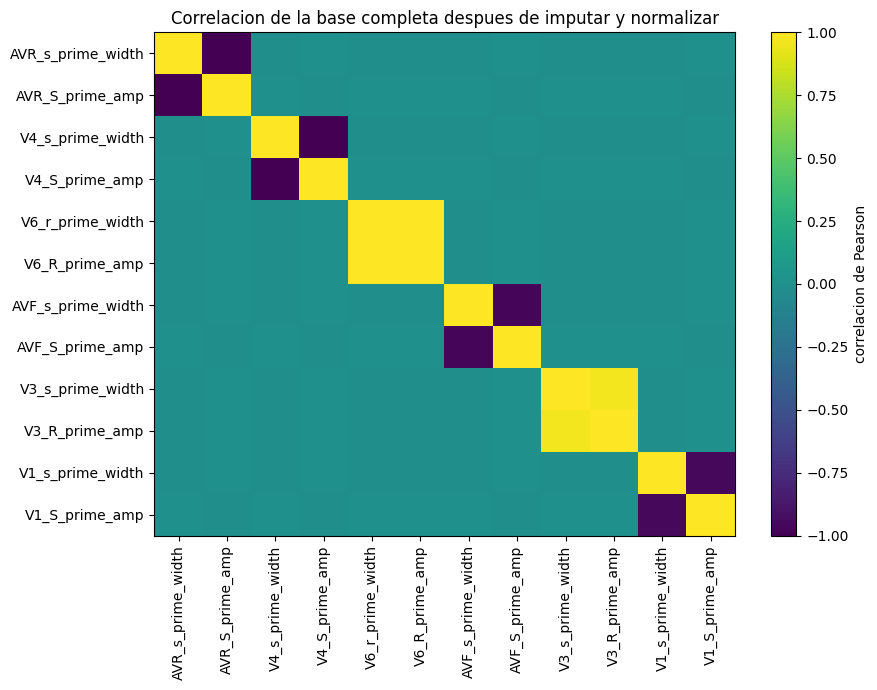

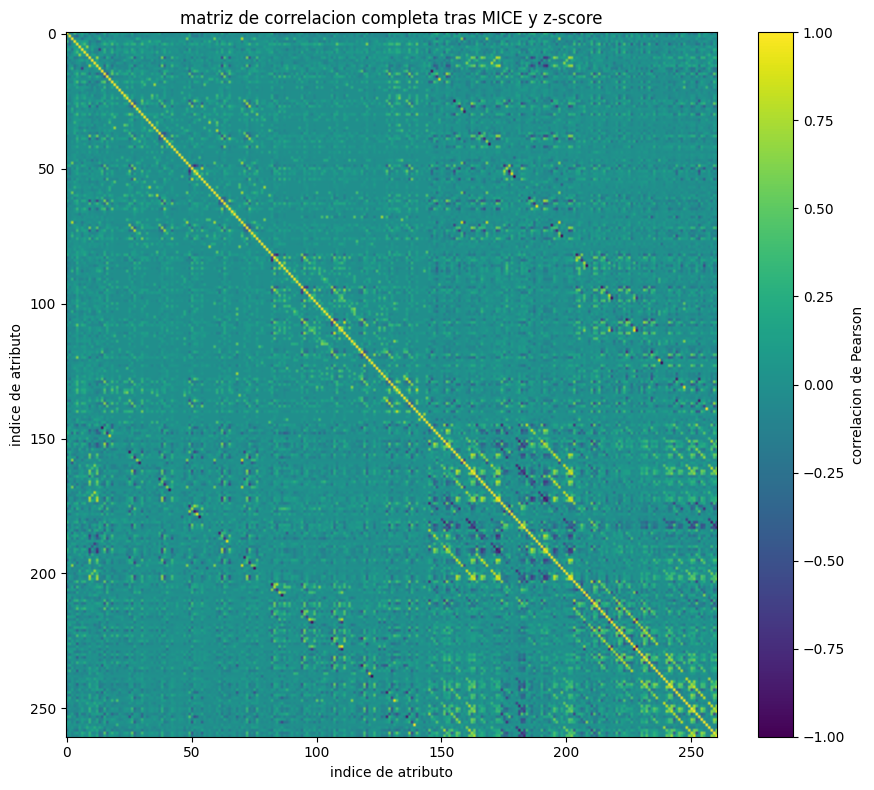

In [11]:
# utiliza exclusivamente los datos ya imputados y normalizados
Z_all = X_z.to_numpy(dtype=float)
n_all, d_all = Z_all.shape

# calcula la covarianza muestral de global normalizado
Sigma_z = np.cov(Z_all, rowvar=False, ddof=1)
Sigma_z_df = pd.DataFrame(
    Sigma_z,
    index=X_z.columns,
    columns=X_z.columns,
)

# calcula la correlacion de los mismos datos normalizados
corr_all = X_z.corr()

# obtiene los pares sin repetir la matriz simetrica
upper = np.triu(np.ones(corr_all.shape, dtype=bool), k=1)
corr_pairs = (
    corr_all.where(upper)
    .stack()
    .rename("corr")
    .reset_index()
    .rename(columns={"level_0": "variable_1", "level_1": "variable_2"})
)

corr_pairs["|corr|"] = corr_pairs["corr"].abs()
corr_pairs = corr_pairs.sort_values("|corr|", ascending=False)

# elige variables representativas para no imprimir una matriz enorme ilegible
top_vars = []
for _, row in corr_pairs.head(25).iterrows():
    for col in [row["variable_1"], row["variable_2"]]:
        if col not in top_vars:
            top_vars.append(col)
        if len(top_vars) >= 12:
            break
    if len(top_vars) >= 12:
        break

if len(top_vars) < 2:
    top_vars = list(X_z.columns[:min(12, d_all)])

print("=" * 80)
print("COVARIANZA Y CORRELACION DESPUES DE NORMALIZAR")
print("=" * 80)
print(f"datos completos normalizados   : {Z_all.shape}")
print(f"matriz de covarianza completa  : {Sigma_z_df.shape}")
print(f"traza de Sigma_z              : {np.trace(Sigma_z):.8f}")
print(f"varianza promedio en diagonal : {np.trace(Sigma_z)/d_all:.8f}")

print("\nmatriz de covarianza normalizada - submatriz representativa")
display(Sigma_z_df.loc[top_vars, top_vars].round(4))

print("\nmatriz de correlacion - submatriz representativa")
display(corr_all.loc[top_vars, top_vars].round(4))

print("\n20 pares con mayor correlacion absoluta")
display(corr_pairs.head(20).round(5))

high_corr_count = int((corr_pairs["|corr|"] >= 0.95).sum())
print(f"\npares con |corr| >= 0.95: {high_corr_count}")

print("\nDECISION")
if high_corr_count > 0:
    print("se detectan atributos con asociaciones fuertes que pueden causar dependencia lineal")
else:
    print("no se detectan pares con correlacion extrema, pero puede existir dependencia multivariada")
print("se procede al espectro de Sigma_z antes de elegir la regularizacion")

plt.figure(figsize=(9, 7))
plt.imshow(
    corr_all.loc[top_vars, top_vars].to_numpy(),
    vmin=-1,
    vmax=1,
    aspect="auto",
)
plt.colorbar(label="correlacion de Pearson")
plt.xticks(range(len(top_vars)), top_vars, rotation=90)
plt.yticks(range(len(top_vars)), top_vars)
plt.title("Correlacion de la base completa despues de imputar y normalizar")
plt.tight_layout()
plt.show()

# conserva la matriz completa accesible sin saturar la salida principal
MOSTRAR_MATRIZ_COMPLETA = False
if MOSTRAR_MATRIZ_COMPLETA:
    with pd.option_context("display.max_rows", None, "display.max_columns", None):
        display(Sigma_z_df.round(5))

# visualiza la matriz de correlacion completa para localizar bloques de dependencia
plt.figure(figsize=(9, 8))
plt.imshow(corr_all.to_numpy(), vmin=-1, vmax=1, aspect="auto")
plt.colorbar(label="correlacion de Pearson")
plt.xlabel("indice de atributo")
plt.ylabel("indice de atributo")
plt.title("matriz de correlacion completa tras MICE y z-score")
plt.tight_layout()
plt.show()

## 5. Diagnóstico espectral y número de condición previo a regularizar

Se calculan el rango de la matriz normalizada, los autovalores de la covarianza, las direcciones casi degeneradas y el número de condición

$$
\Sigma_Z v_i = \lambda_i v_i,\qquad
\kappa(\Sigma_Z)=\frac{\lambda_{\max}}{\lambda_{\min}}
$$

Si la covarianza es singular, el número de condición es infinito en aritmética exacta; NumPy puede producir un número finito muy grande debido al redondeo

ANALISIS ESTRUCTURAL DE BASE COMPLETA NORMALIZADO
Z pertenece a R^(452 x 261)
rank(Z)                         = 257
deficiencia de rango            = 4
rank(Sigma_z)                   = 257
kappa(Sigma_z)                  = 1.208496e+17
kappa(H_z = Z^T Z/n)            = 5.063560e+17
autovalor minimo de Sigma_z     = -1.347529e-15
autovalor maximo de Sigma_z     = 2.085137e+01
autovalores < 1e-10             = 4

10 mayores autovalores de Sigma_z


,indice,autovalor
0,1,20.851371
1,2,18.516760
2,3,13.820408
3,4,12.127309
4,5,9.739926
5,6,8.915306
6,7,7.327392
7,8,6.990517
8,9,6.053135
9,10,5.951739



10 menores autovalores de Sigma_z


,indice_desde_el_minimo,autovalor
0,1,-0.000000
1,2,-0.000000
2,3,-0.000000
3,4,0.000000
4,5,0.000005
5,6,0.000166
6,7,0.000348
7,8,0.000389
8,9,0.000453
9,10,0.000493



DECISION
el espectro evidencia singularidad, direcciones casi degeneradas o condicionamiento elevado
se justifica regularizar la covarianza antes de invertirla


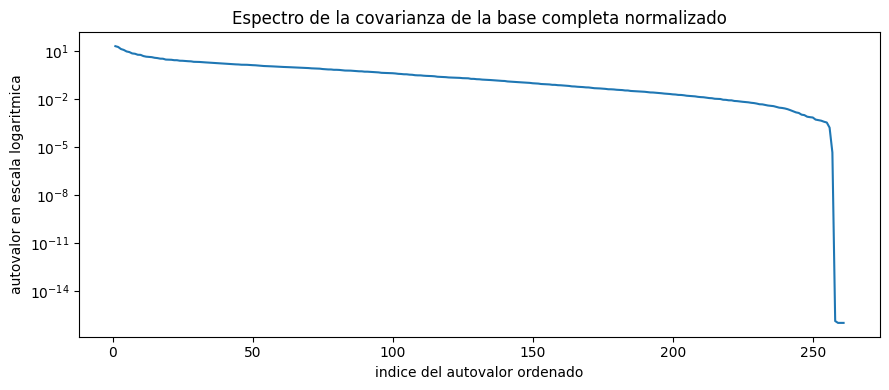

In [12]:
# analiza la geometria de train una vez normalizado
rank_Z = np.linalg.matrix_rank(Z_all)
rank_deficiency = d_all - rank_Z

# matriz de gram escalada para el analisis del hessiano
H_z = (Z_all.T @ Z_all) / n_all

# calcula los autovalores de la covarianza simetrica
sigma_eigs = np.linalg.eigvalsh(Sigma_z)
sigma_eigs_desc = sigma_eigs[::-1]

lambda_min_emp = float(sigma_eigs.min())
lambda_max_emp = float(sigma_eigs.max())
rank_Sigma_z = np.linalg.matrix_rank(Sigma_z)
near_zero = int((sigma_eigs < 1e-10).sum())

# mide la condicion numerica antes de la regularizacion
cond_Sigma_z = np.linalg.cond(Sigma_z)
cond_H_z = np.linalg.cond(H_z)

print("=" * 80)
print("ANALISIS ESTRUCTURAL DE BASE COMPLETA NORMALIZADO")
print("=" * 80)
print(f"Z pertenece a R^({n_all} x {d_all})")
print(f"rank(Z)                         = {rank_Z}")
print(f"deficiencia de rango            = {rank_deficiency}")
print(f"rank(Sigma_z)                   = {rank_Sigma_z}")
print(f"kappa(Sigma_z)                  = {cond_Sigma_z:.6e}")
print(f"kappa(H_z = Z^T Z/n)            = {cond_H_z:.6e}")
print(f"autovalor minimo de Sigma_z     = {lambda_min_emp:.6e}")
print(f"autovalor maximo de Sigma_z     = {lambda_max_emp:.6e}")
print(f"autovalores < 1e-10             = {near_zero}")

print("\n10 mayores autovalores de Sigma_z")
display(pd.DataFrame({
    "indice": np.arange(1, min(10, d_all)+1),
    "autovalor": sigma_eigs_desc[:10],
}).round(9))

print("\n10 menores autovalores de Sigma_z")
display(pd.DataFrame({
    "indice_desde_el_minimo": np.arange(1, min(10, d_all)+1),
    "autovalor": sigma_eigs[:10],
}).round(12))

print("\nDECISION")
if rank_deficiency > 0 or near_zero > 0 or cond_Sigma_z > 1e4:
    print("el espectro evidencia singularidad, direcciones casi degeneradas o condicionamiento elevado")
    print("se justifica regularizar la covarianza antes de invertirla")
else:
    print("la matriz esta razonablemente condicionada; se comprobara si necesita solo un ajuste numerico minimo")

plt.figure(figsize=(9, 4))
plt.semilogy(
    np.arange(1, d_all + 1),
    np.clip(sigma_eigs_desc, 1e-16, None),
)
plt.xlabel("indice del autovalor ordenado")
plt.ylabel("autovalor en escala logaritmica")
plt.title("Espectro de la covarianza de la base completa normalizado")
plt.tight_layout()
plt.show()

## 6. Regularización de la matriz de covarianza

Se calcula una regularización adaptativa que busque $\kappa(\Sigma_Z+\lambda I)\le10^4$

$$
\Sigma_{\rm reg}=\Sigma_Z+\lambda I,\qquad
\lambda\ge\max\left\{0,\frac{\lambda_{\max}-10^4\lambda_{\min}}{10^4-1}\right\}
$$

La matriz de datos `X_z` **no se altera** al sumar \(\lambda I\); la matriz regularizada se emplea cuando se requiere invertir una covarianza estable

REGULARIZACION DE LA MATRIZ DE COVARIANZA
kappa objetivo                   = 1.000000e+04
autovalor minimo antes           = -1.347529e-15
autovalor maximo antes           = 2.085137e+01
kappa(Sigma_z) antes             = 1.208496e+17
lambda minimo teorico            = 2.085346e-03
lambda de proteccion numerica    = 1.002217e-10
lambda elegido                   = 2.085346e-03
autovalor minimo despues         = 2.085346e-03
autovalor maximo despues         = 2.085346e+01
kappa(Sigma_reg) despues         = 1.000000e+04
kappa(H_z) antes                 = 5.063560e+17
kappa(H_ridge) despues           = 9.955806e+03

submatriz de covarianza regularizada


,AVR_s_prime_width,AVR_S_prime_amp,V4_s_prime_width,V4_S_prime_amp,V6_r_prime_width,V6_R_prime_amp,AVF_s_prime_width,AVF_S_prime_amp,V3_s_prime_width,V3_R_prime_amp,V1_s_prime_width,V1_S_prime_amp
AVR_s_prime_width,1.00430,-1.00222,-0.00289,0.00294,-0.00380,-0.00375,-0.00374,0.00343,-0.00308,-0.00399,-0.00354,0.00296
AVR_S_prime_amp,-1.00222,1.00430,0.00289,-0.00294,0.00380,0.00375,0.00374,-0.00343,0.00308,0.00399,0.00354,-0.00296
V4_s_prime_width,-0.00289,0.00289,1.00430,-1.00150,-0.00495,-0.00488,-0.00487,0.00446,-0.00401,-0.00519,-0.00460,0.00384
V4_S_prime_amp,0.00294,-0.00294,-1.00150,1.00430,0.00503,0.00496,0.00495,-0.00453,0.00408,0.00527,0.00467,-0.00390
V6_r_prime_width,-0.00380,0.00380,-0.00495,0.00503,1.00430,0.99998,-0.00641,0.00587,-0.00528,-0.00683,-0.00605,0.00506
V6_R_prime_amp,-0.00375,0.00375,-0.00488,0.00496,0.99998,1.00430,-0.00633,0.00579,-0.00521,-0.00674,-0.00597,0.00499
AVF_s_prime_width,-0.00374,0.00374,-0.00487,0.00495,-0.00641,-0.00633,1.00430,-0.96950,-0.00520,-0.00672,-0.00596,0.00498
AVF_S_prime_amp,0.00343,-0.00343,0.00446,-0.00453,0.00587,0.00579,-0.96950,1.00430,0.00476,0.00615,0.00545,-0.00456
V3_s_prime_width,-0.00308,0.00308,-0.00401,0.00408,-0.00528,-0.00521,-0.00520,0.00476,1.00430,0.96881,-0.00491,0.00410
V3_R_prime_amp,-0.00399,0.00399,-0.00519,0.00527,-0.00683,-0.00674,-0.00672,0.00615,0.96881,1.00430,-0.00635,0.00531



DECISION
la regularizacion alcanza el objetivo de condicionamiento numerico
la inversa regularizada se utilizara para Mahalanobis


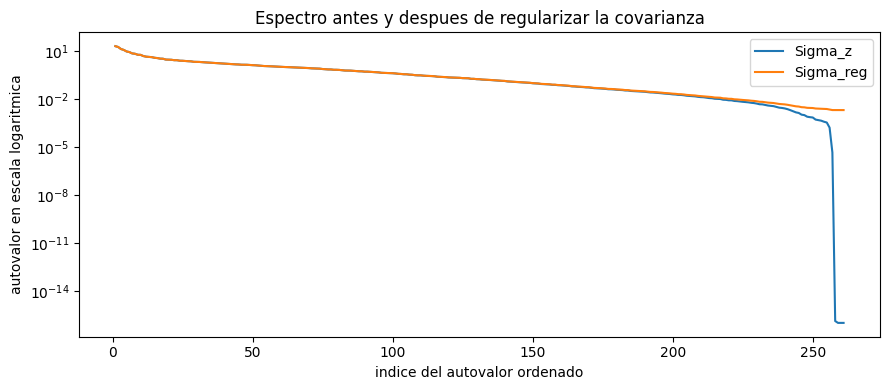


SIGUIENTE ETAPA: se estratifican las observaciones ya completas y normalizadas


In [13]:
# usa exclusivamente el espectro calculado de Sigma_z
kappa_target = 1e4

# corrige pequeños autovalores negativos debidos al redondeo
lambda_min_nonnegative = max(0.0, lambda_min_emp)

# determina el lambda suficiente para alcanzar el condicionamiento objetivo
lambda_needed = max(
    0.0,
    (lambda_max_emp - kappa_target * lambda_min_nonnegative) / (kappa_target - 1.0),
)

# incluye una proteccion numerica proporcional a la escala de la covarianza
lambda_floor = 1e-10 * max(1.0, np.trace(Sigma_z) / d_all)
lambda_cov = max(lambda_needed, lambda_floor)

# regulariza la misma matriz de covarianza que se acaba de inspeccionar
Sigma_reg = Sigma_z + lambda_cov * np.eye(d_all)
Sigma_reg_df = pd.DataFrame(
    Sigma_reg,
    index=X_z.columns,
    columns=X_z.columns,
)

# comprueba el resultado con el espectro y el numero de condicion
sigma_eigs_reg = np.linalg.eigvalsh(Sigma_reg)
cond_Sigma_reg = np.linalg.cond(Sigma_reg)

# muestra tambien el efecto equivalente en la matriz H del hessiano
scale_H = (n_all - 1) / n_all
lambda_H = lambda_cov / scale_H
H_ridge = H_z + lambda_H * np.eye(d_all)
cond_H_ridge = np.linalg.cond(H_ridge)

print("=" * 80)
print("REGULARIZACION DE LA MATRIZ DE COVARIANZA")
print("=" * 80)
print(f"kappa objetivo                   = {kappa_target:.6e}")
print(f"autovalor minimo antes           = {lambda_min_emp:.6e}")
print(f"autovalor maximo antes           = {lambda_max_emp:.6e}")
print(f"kappa(Sigma_z) antes             = {cond_Sigma_z:.6e}")
print(f"lambda minimo teorico            = {lambda_needed:.6e}")
print(f"lambda de proteccion numerica    = {lambda_floor:.6e}")
print(f"lambda elegido                   = {lambda_cov:.6e}")
print(f"autovalor minimo despues         = {sigma_eigs_reg.min():.6e}")
print(f"autovalor maximo despues         = {sigma_eigs_reg.max():.6e}")
print(f"kappa(Sigma_reg) despues         = {cond_Sigma_reg:.6e}")
print(f"kappa(H_z) antes                 = {cond_H_z:.6e}")
print(f"kappa(H_ridge) despues           = {cond_H_ridge:.6e}")

print("\nsubmatriz de covarianza regularizada")
display(Sigma_reg_df.loc[top_vars, top_vars].round(5))

print("\nDECISION")
if cond_Sigma_reg <= 1.05 * kappa_target:
    print("la regularizacion alcanza el objetivo de condicionamiento numerico")
else:
    print("el objetivo no se alcanzo con la tolerancia prevista")
    print("se recomienda revisar las tolerancias y reducir dimensionalidad si fuera necesario")
print("la inversa regularizada se utilizara para Mahalanobis")

plt.figure(figsize=(9, 4))
plt.semilogy(
    np.arange(1, d_all + 1),
    np.clip(sigma_eigs_desc, 1e-16, None),
    label="Sigma_z",
)
plt.semilogy(
    np.arange(1, d_all + 1),
    sigma_eigs_reg[::-1],
    label="Sigma_reg",
)
plt.xlabel("indice del autovalor ordenado")
plt.ylabel("autovalor en escala logaritmica")
plt.title("Espectro antes y despues de regularizar la covarianza")
plt.legend()
plt.tight_layout()
plt.show()
print("\nSIGUIENTE ETAPA: se estratifican las observaciones ya completas y normalizadas")

## 7. Particionamiento estratificado al finalizar el tratamiento estructural

Solo en esta etapa se generan Train y Test a partir de `X_z` y `y_raw`. La división conserva aproximadamente la proporción de cada clase. Se protege el caso de una clase que solo tiene una observación, que permanece en Train

**Importante:** aunque Test no se usa para detectar o balancear atípicos en las etapas siguientes, sus predictores ya influyeron en la imputación y normalización globales anteriores. Por tanto, este Test no constituye una evaluación completamente independiente del preprocesamiento

In [14]:
def stratified_split_numpy(X, y, test_size=0.20, seed=42):
    # crea un generador reproducible
    rng = np.random.default_rng(seed)

    # prepara los indices de train y test
    train_idx, test_idx = [], []
    y_arr = y.to_numpy()

    # procesa cada clase de manera independiente
    for clase in np.sort(y.unique()):
        idx = np.where(y_arr == clase)[0]
        rng.shuffle(idx)
        n_c = len(idx)

        # protege clases con una sola observacion
        if n_c <= 1:
            n_test = 0
        else:
            n_test = int(round(test_size * n_c))
            n_test = max(1, n_test)
            n_test = min(n_test, n_c - 1)

        test_idx.extend(idx[:n_test])
        train_idx.extend(idx[n_test:])

    train_idx = np.array(train_idx, dtype=int)
    test_idx = np.array(test_idx, dtype=int)

    rng.shuffle(train_idx)
    rng.shuffle(test_idx)

    return (
        X.iloc[train_idx].reset_index(drop=True),
        X.iloc[test_idx].reset_index(drop=True),
        y.iloc[train_idx].reset_index(drop=True),
        y.iloc[test_idx].reset_index(drop=True),
    )



# estratifica solamente despues de imputar, normalizar y regularizar la covarianza
X_train_z, X_test_z, y_train, y_test = stratified_split_numpy(
    X_z,
    y_raw,
    test_size=0.20,
    seed=42,
)

# conserva tambien las versiones completas sin normalizar con exactamente la misma particion
X_train_imp, X_test_imp, y_train_check, y_test_check = stratified_split_numpy(
    X_complete,
    y_raw,
    test_size=0.20,
    seed=42,
)
assert y_train.equals(y_train_check)
assert y_test.equals(y_test_check)

class_split_report = pd.concat(
    [
        y_raw.value_counts().sort_index().rename("total"),
        y_train.value_counts().sort_index().rename("train"),
        y_test.value_counts().sort_index().rename("test"),
    ], axis=1
).fillna(0).astype(int)
class_split_report["prop_train"] = class_split_report["train"] / class_split_report["total"]
class_split_report["prop_test"] = class_split_report["test"] / class_split_report["total"]

print("=" * 80)
print("PARTICION ESTRATIFICADA FINAL")
print("=" * 80)
print(f"X_train_z                      : {X_train_z.shape}")
print(f"X_test_z                       : {X_test_z.shape}")
print(f"faltantes en Train             : {int(X_train_z.isna().sum().sum())}")
print(f"faltantes en Test              : {int(X_test_z.isna().sum().sum())}")
display(class_split_report.round(4))
assert not X_train_z.isna().any().any()
assert not X_test_z.isna().any().any()
print("\nDECISION")
print("la estratificacion se realiza despues de las etapas solicitadas")
print("la limpieza exploratoria y el balance posteriores se restringen a Train")

PARTICION ESTRATIFICADA FINAL
X_train_z                      : (360, 261)
X_test_z                       : (92, 261)
faltantes en Train             : 0
faltantes en Test              : 0


,total,train,test,prop_train,prop_test
Clase,,,,,
1,245,196,49,0.8000,0.2000
2,44,35,9,0.7955,0.2045
3,15,12,3,0.8000,0.2000
4,15,12,3,0.8000,0.2000
5,13,10,3,0.7692,0.2308
6,25,20,5,0.8000,0.2000
7,3,2,1,0.6667,0.3333
8,2,1,1,0.5000,0.5000
9,9,7,2,0.7778,0.2222



DECISION
la estratificacion se realiza despues de las etapas solicitadas
la limpieza exploratoria y el balance posteriores se restringen a Train


## 8. Detección exploratoria de posibles observaciones atípicas sobre Train

Se calcula la distancia de Mahalanobis usando la covarianza regularizada previamente obtenida. El umbral $D_M^2>d+3\sqrt{2d}$ es exploratorio, **no un contraste exacto** bajo regularización y estimación muestral

MAHALANOBIS CON COVARIANZA PREVIAMENTE REGULARIZADA
dimension d                    = 261
kappa(Sigma_reg)               = 1.000000e+04
lambda_cov                     = 2.085346e-03
umbral aproximado              = 18.15329
registros marcados             = 81 de 360
porcentaje marcado             = 22.50%

20 distancias mas grandes


,indice_train,Clase,Mahalanobis,outlier
118,118,1,21.19305,True
209,209,5,21.18841,True
107,107,1,21.18816,True
97,97,10,21.18748,True
268,268,1,21.18321,True
50,50,1,21.18316,True
101,101,3,21.18270,True
9,9,1,21.18228,True
184,184,9,21.18227,True
144,144,2,21.18218,True



conteo de candidatos por clase


,candidatos
Clase,
1,23
2,12
3,10
4,1
5,5
6,2
9,7
10,14
14,2



DECISION
los registros marcados requieren revision y no se consideran ruido demostrado
la depuracion posterior sera conservadora y protegera clases minoritarias


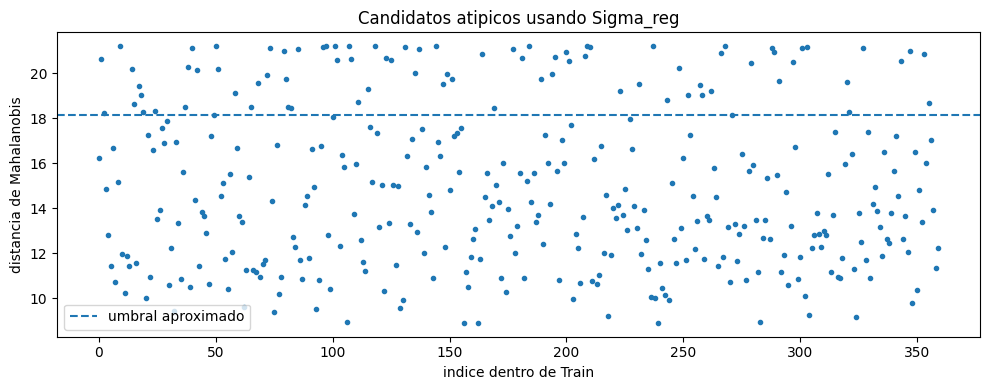

In [16]:
# reutiliza la covarianza regularizada antes de la estratificacion
Z_train = X_train_z.to_numpy(dtype=float)
Sigma_inv = np.linalg.pinv(Sigma_reg, rcond=1e-10)

d = Sigma_reg.shape[0]
mu_z = Z_train.mean(axis=0)
delta = Z_train - mu_z

# calcula simultaneamente las distancias cuadradas
dm2 = np.einsum("ij,jk,ik->i", delta, Sigma_inv, delta)
DM = np.sqrt(np.maximum(dm2, 0.0))

# define un umbral exploratorio que no es un test exacto bajo regularizacion
threshold2 = d + 3 * np.sqrt(2 * d)
threshold_DM = np.sqrt(threshold2)

outlier_mask = DM > threshold_DM
outlier_idx = np.where(outlier_mask)[0]

outlier_table = pd.DataFrame({
    "indice_train": np.arange(len(DM)),
    "Clase": y_train.to_numpy(),
    "Mahalanobis": DM,
    "outlier": outlier_mask,
}).sort_values("Mahalanobis", ascending=False)

print("=" * 80)
print("MAHALANOBIS CON COVARIANZA PREVIAMENTE REGULARIZADA")
print("=" * 80)
print(f"dimension d                    = {d}")
print(f"kappa(Sigma_reg)               = {cond_Sigma_reg:.6e}")
print(f"lambda_cov                     = {lambda_cov:.6e}")
print(f"umbral aproximado              = {threshold_DM:.5f}")
print(f"registros marcados             = {len(outlier_idx)} de {len(DM)}")
print(f"porcentaje marcado             = {100*outlier_mask.mean():.2f}%")

print("\n20 distancias mas grandes")
display(outlier_table.head(20).round(5))

print("\nconteo de candidatos por clase")
display(
    outlier_table.loc[outlier_table["outlier"], "Clase"]
    .value_counts()
    .sort_index()
    .rename("candidatos")
    .to_frame()
)

print("\nDECISION")
print("los registros marcados requieren revision y no se consideran ruido demostrado")
print("la depuracion posterior sera conservadora y protegera clases minoritarias")

plt.figure(figsize=(10, 4))
plt.plot(np.arange(len(DM)), DM, ".")
plt.axhline(threshold_DM, linestyle="--", label="umbral aproximado")
plt.xlabel("indice dentro de Train")
plt.ylabel("distancia de Mahalanobis")
plt.title("Candidatos atipicos usando Sigma_reg")
plt.legend()
plt.tight_layout()
plt.show()